# Cards Dataset EDA

In [2]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "cards.csv"

In [3]:
df = pd.read_csv(CSV_PATH)
df.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


In [4]:
df.shape

(8155, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8155 entries, 0 to 8154
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   class index  8155 non-null   int64
 1   filepaths    8155 non-null   str  
 2   labels       8155 non-null   str  
 3   card type    8155 non-null   str  
 4   data set     8155 non-null   str  
dtypes: int64(1), str(4)
memory usage: 318.7 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique()

class index      53
filepaths      8155
labels           53
card type        14
data set          3
dtype: int64

I recognise the absurdity of including the Joker in the context of blackjack counting, so I'm going to remove it entirely from the dataset.

In [31]:
df = df[df["labels"] != "joker"].reset_index(drop=True)
df.nunique()

class index      52
filepaths      8030
labels           52
card type        13
data set          3
dtype: int64

## Split sizes

In [32]:
split_counts = df["data set"].value_counts()
split_counts

data set
train    7510
test      260
valid     260
Name: count, dtype: int64

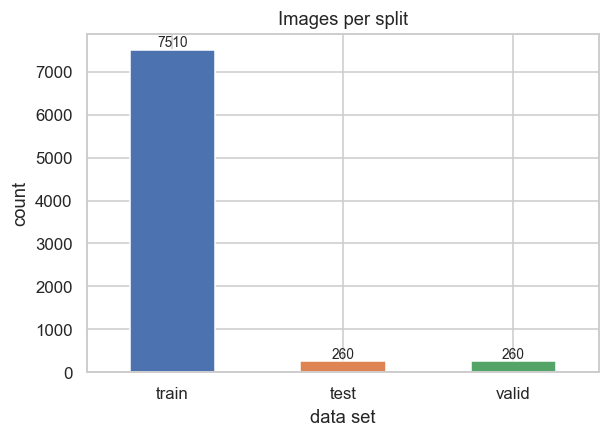

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
split_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A467"], ax=ax)
ax.set_title("Images per split")
ax.set_ylabel("count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=0)
plt.show()

## Per-class distribution

In [34]:
label_counts = df["labels"].value_counts()
label_counts.describe()

count     52.000000
mean     154.423077
std       17.048197
min      118.000000
25%      139.750000
50%      152.500000
75%      168.000000
max      191.000000
Name: count, dtype: float64

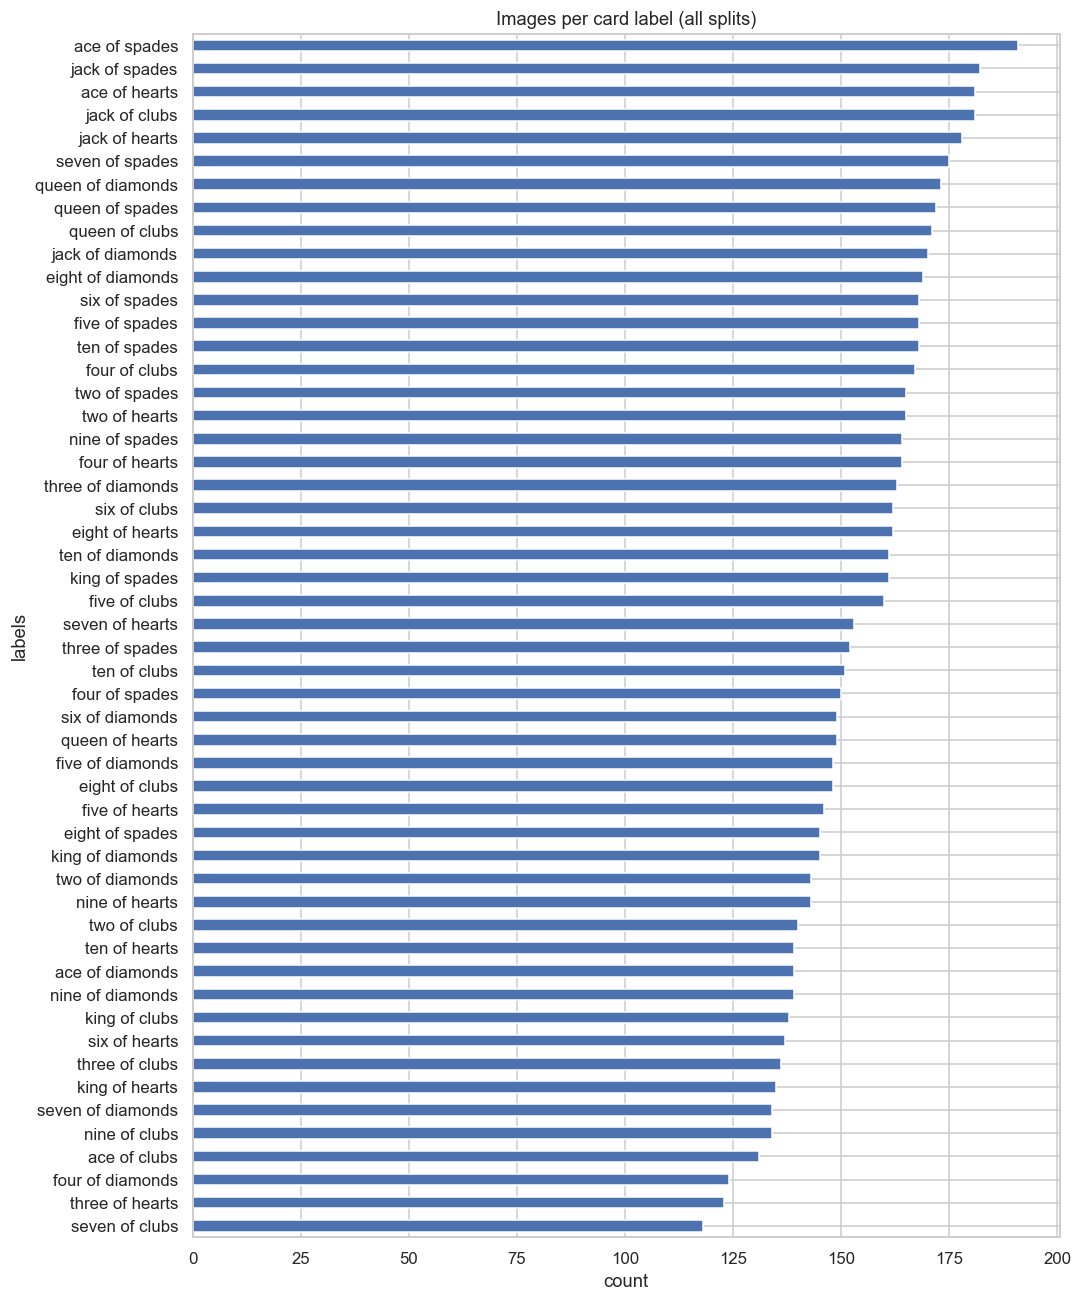

In [35]:
fig, ax = plt.subplots(figsize=(10, 12))
label_counts.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_title("Images per card label (all splits)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

In [36]:
pivot = df.pivot_table(index="labels", columns="data set",
                       values="filepaths", aggfunc="count", fill_value=0)
pivot = pivot[["train", "valid", "test"]]
pivot.head()

data set,train,valid,test
labels,,,
ace of clubs,121,5,5
ace of diamonds,129,5,5
ace of hearts,171,5,5
ace of spades,181,5,5
eight of clubs,138,5,5


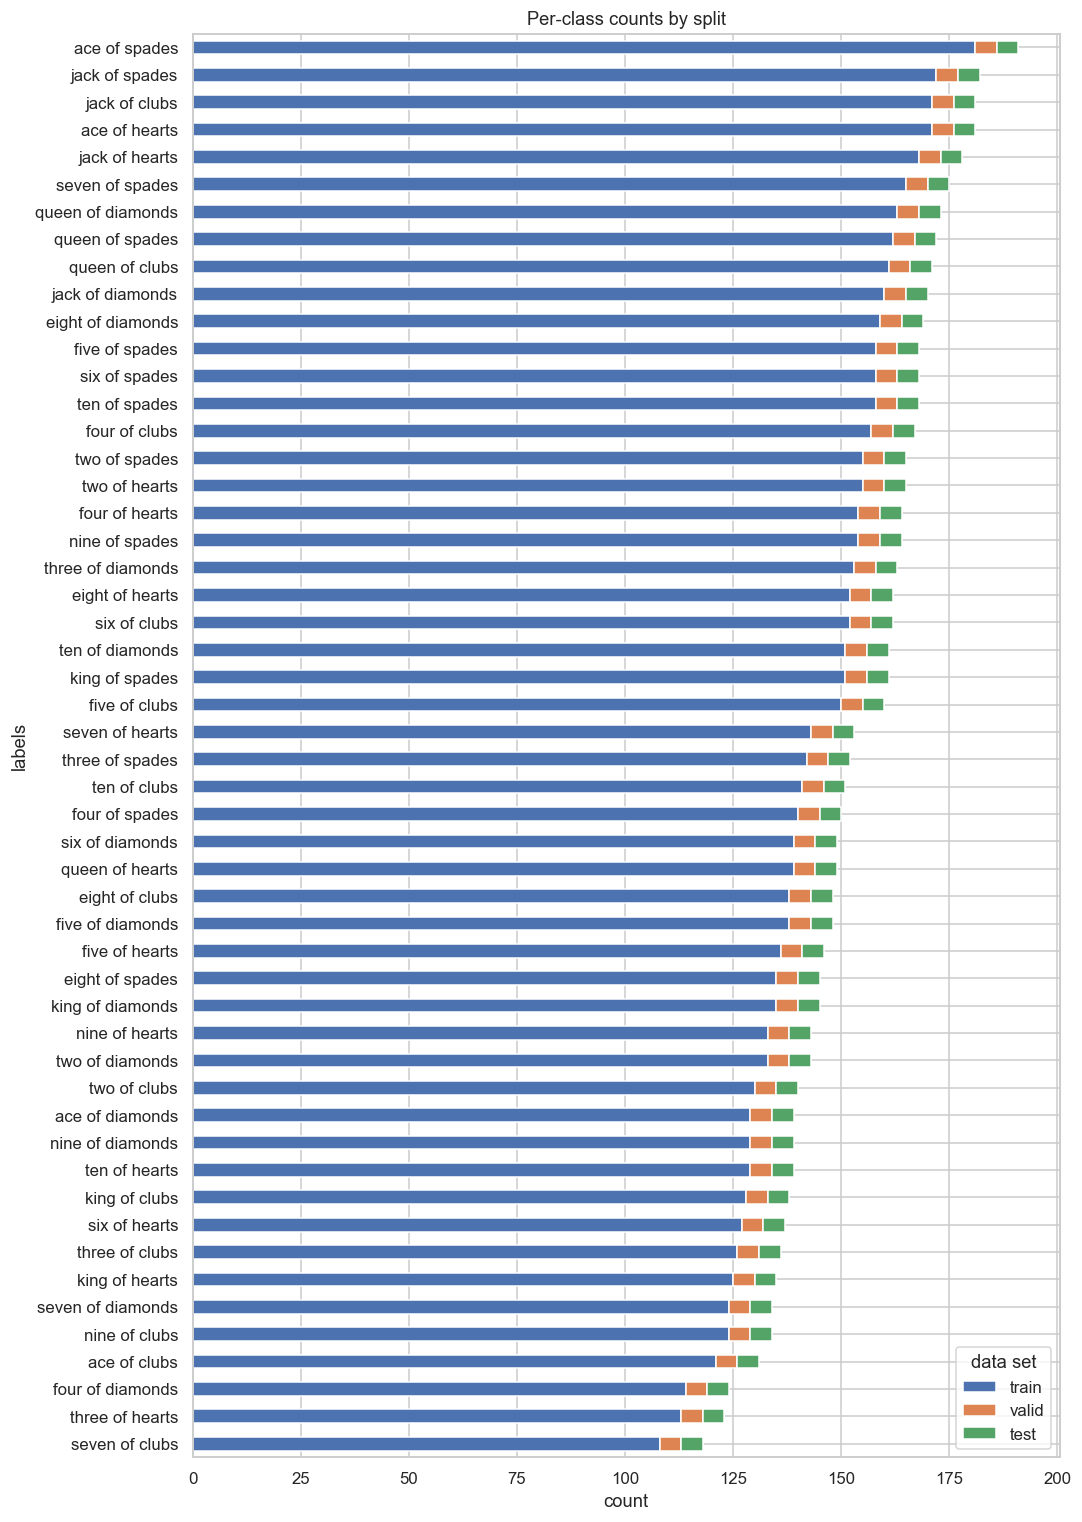

In [37]:
fig, ax = plt.subplots(figsize=(10, 14))
pivot.sort_values("train").plot(kind="barh", stacked=True, ax=ax,
                                color=["#4C72B0", "#DD8452", "#55A467"])
ax.set_title("Per-class counts by split")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

## Card type (rank) distribution

In [38]:
type_counts = df["card type"].value_counts()
type_counts

card type
jack     711
queen    665
ace      642
eight    624
five     622
ten      619
six      616
two      613
four     605
nine     580
seven    580
king     579
three    574
Name: count, dtype: int64

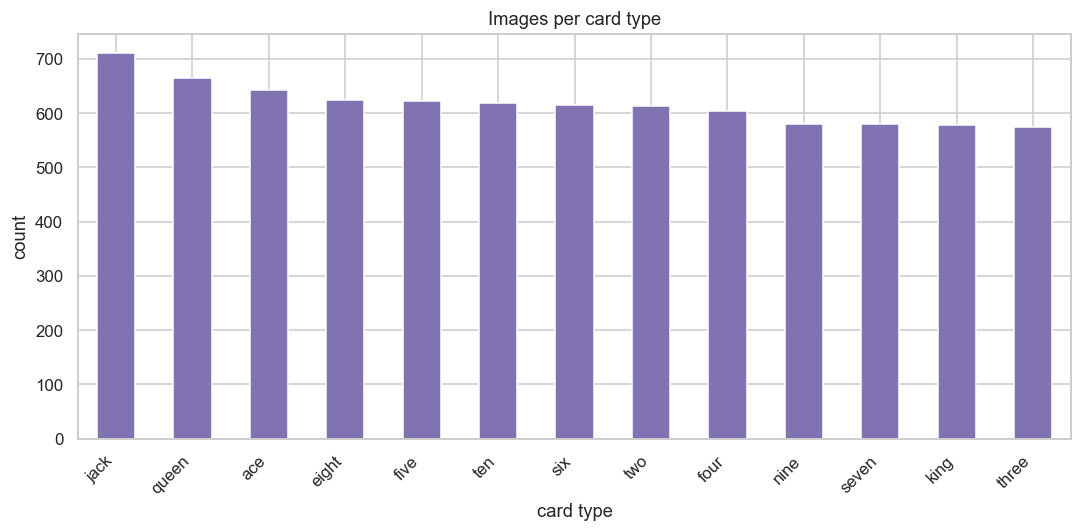

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
type_counts.plot(kind="bar", color="#8172B2", ax=ax)
ax.set_title("Images per card type")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Suits

In [40]:
def extract_suit(label):
    for s in ("clubs", "diamonds", "hearts", "spades"):
        if s in label:
            return s
    return "joker"

df["suit"] = df["labels"].apply(extract_suit)
df["suit"].value_counts()

suit
spades      2161
hearts      1975
diamonds    1957
clubs       1937
Name: count, dtype: int64

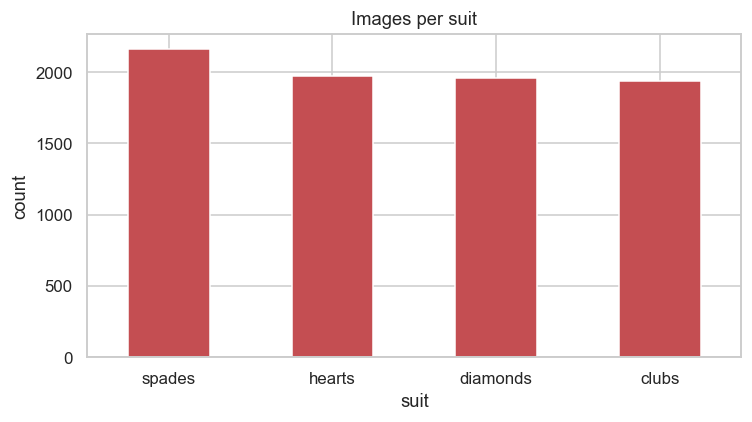

In [41]:
fig, ax = plt.subplots(figsize=(7, 4))
df["suit"].value_counts().plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Images per suit")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Image properties
Sampled to keep it fast.

## Sample images

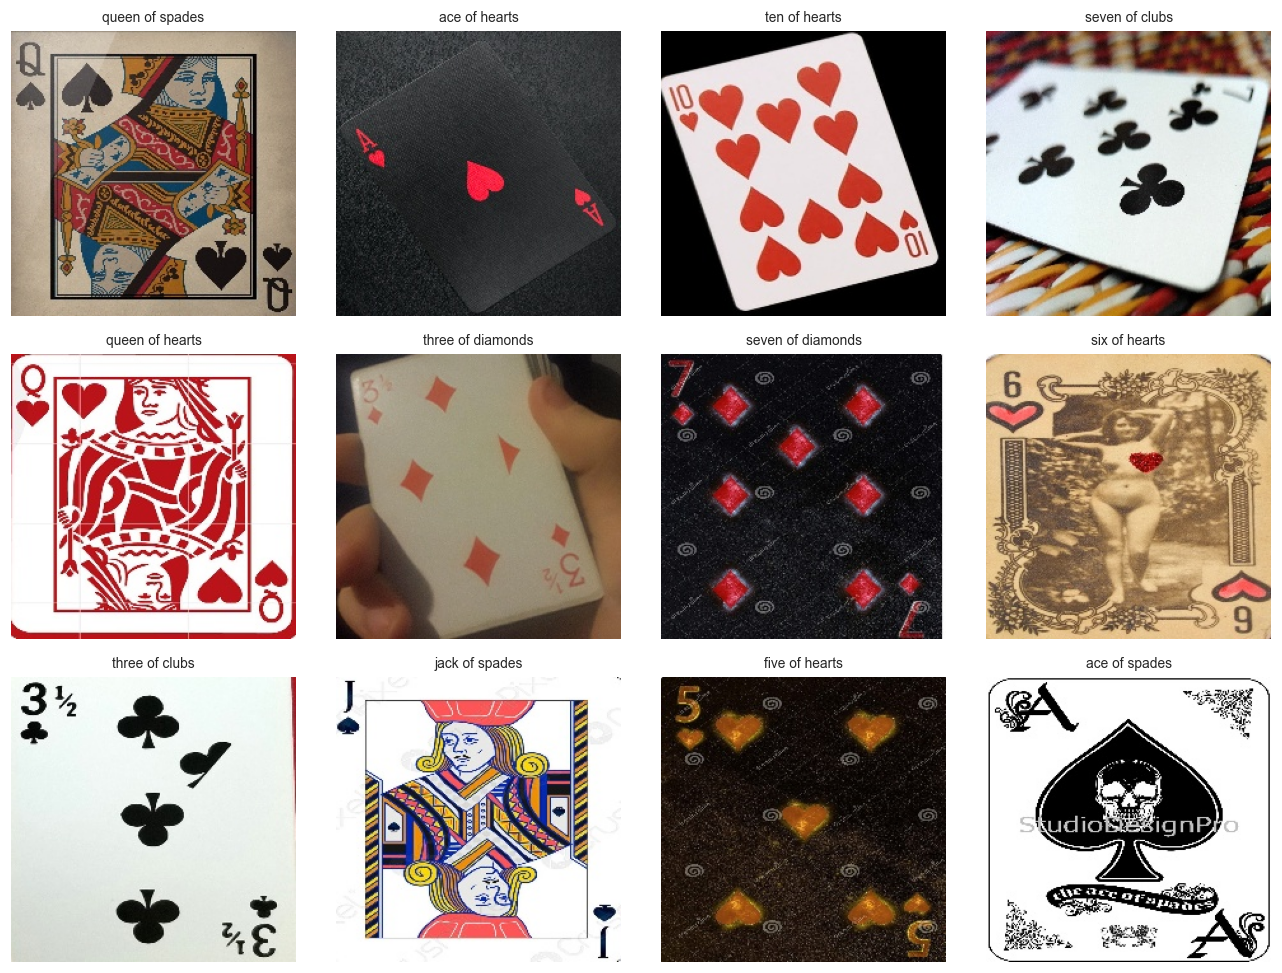

In [42]:
labels_to_show = df["labels"].drop_duplicates().sample(12, random_state=1).tolist()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, label in zip(axes.flat, labels_to_show):
    rel = df[df["labels"] == label]["filepaths"].iloc[0]
    ax.imshow(Image.open(DATA_DIR / rel))
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Variation within a single class

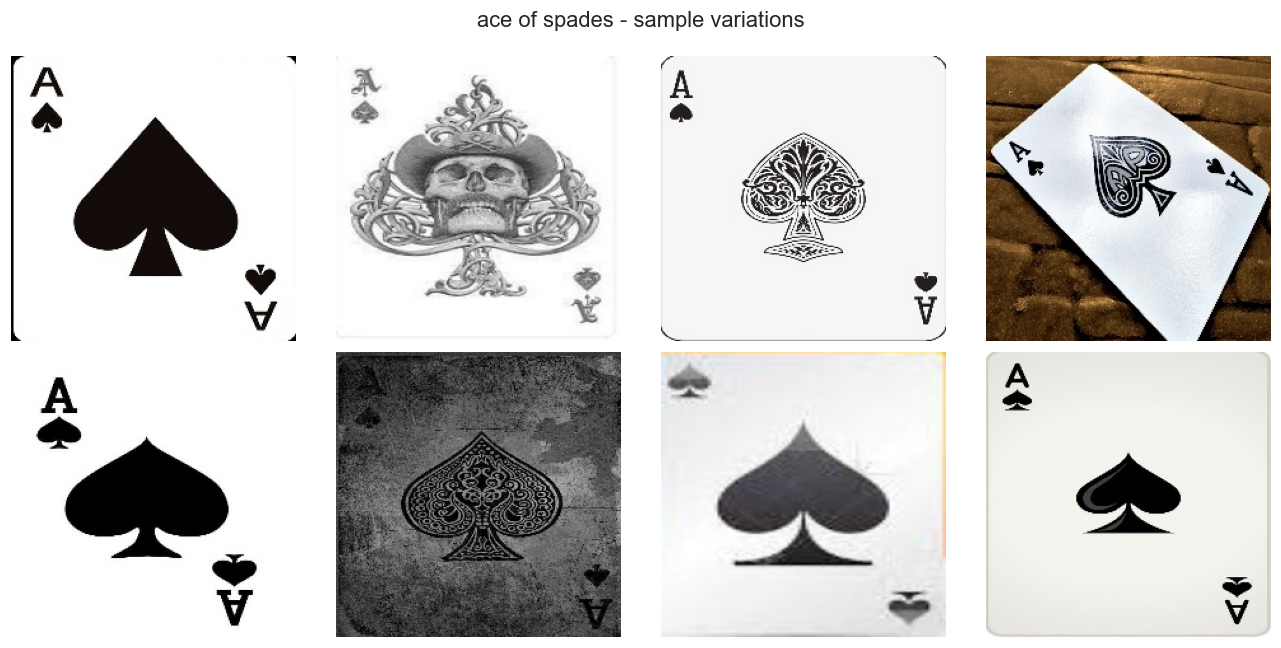

In [43]:
target = "ace of spades"
samples = df[df["labels"] == target].sample(8, random_state=2)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, rel in zip(axes.flat, samples["filepaths"]):
    ax.imshow(Image.open(DATA_DIR / rel))
    ax.axis("off")
fig.suptitle(f"{target} - sample variations")
plt.tight_layout()
plt.show()